<a href="https://colab.research.google.com/github/PozieSwagger/lis4693/blob/main/Lab-7/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7: Sentiment Analysis

Within this lab we are utilizing nltk to analysis data using Sentiment Analysis.

## Task 1: The Bulk of Code

### Install and Load Libraries

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

### Load the Dataset


In [ ]:
import requests
import io

url = "https://raw.githubusercontent.com/PozieSwagger/lis4693/refs/heads/main/Lab-4/train.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

df = pd.read_csv(io.StringIO(text))

#Add an index column
df['Index'] = df.index
print(df.head())

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  Index  
0  Reuters - Short-sellers, Wall Street's dwindli...      0  
1  Reuters - Private investment firm Carlyle Grou...      1  
2  Reuters - Soaring crude prices plus worries\ab...      2  
3  Reuters - Authorities have halted oil export\f...      3  
4  AFP - Tearaway world oil prices, toppling reco...      4  


### Preprocessing

Going through the data and clean up anything that would affect the analysis processes later down the line. For this dataset the 'text' field being chosen is the 'Description' column from the AG News Dataset

In [ ]:
df_subset = df[['Index', 'Description']].copy()
df_subset['Description'] = df_subset['Description'].str.casefold()
df_subset['Description'] = df_subset['Description'].str.replace("[^a-z#]", " ")

### Generating Sentiment Poloarity Scores

In [ ]:
df1 = pd.DataFrame()
df1['Index'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Description']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'Index': row['Index'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

Processing sentiment analysis...


In [ ]:
# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

    Index sentiment_type  sentiment_score
3       0       compound           0.0000
7       1       compound           0.3612
11      2       compound          -0.5719
15      3       compound          -0.1531
19      4       compound          -0.6705
23      5       compound           0.4215
27      6       compound           0.1779
31      7       compound           0.6597
35      8       compound          -0.0516
39      9       compound           0.0000


The columns to be merge would have been a with the 'Index'. As it would allow for the merging of the df together without issue of similar numbers like using 'Class Index'.

In [ ]:
df_output = pd.merge(df, t_df_cleaned, on='Index', how='inner')
print(df_output.head(10))

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   
5            3        Stocks End Up, But Near Year Lows (Reuters)   
6            3               Money Funds Fell in Latest Week (AP)   
7            3  Fed minutes show dissent over inflation (USATO...   
8            3                            Safety Net (Forbes.com)   
9            3            Wall St. Bears Claw Back Into the Black   

                                         Description  Index sentiment_type  \
0  Reuters - Short-sellers, Wall Street's dwindli...      0       compound   
1  Reuters - Private investment firm Carlyle Grou...      1       compound   
2  Reu

### Sentiment Output

From the output with 'describe' method has a range that would be understandable as data within this dataset is news articles. As the mean is close to being nuetral and the 50% also connecting with the nuetral sentiment score.

In [ ]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,120000.000000
mean,0.036139
std,0.491204
min,-0.986400
25%,-0.340000
50%,0.000000
75%,0.440400
max,0.991000


### Visual

For the first graph with mean being around the type of 'Class Index' as for this dataset, 'Class Index' is related to type of article being used within this data. Next visual is using altair and looking at the same mean.

<Axes: title={'center': 'Sentiment Score'}, xlabel='Index', ylabel='Mean Sentiment Score'>

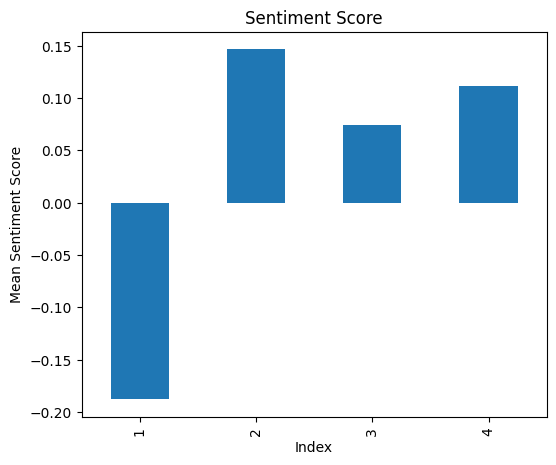

In [ ]:
#generate mean of sentiment_score by period
dfg = df_output.groupby(['Class Index'])['sentiment_score'].mean()
dfg.index = dfg.index.astype(str).str.replace(r'\.0$', '', regex=True)
#create a bar plot
dfg.plot(kind='bar', title='Sentiment Score', ylabel='Mean Sentiment Score',
         xlabel='Index', figsize=(6, 5))

In [ ]:
import altair as alt

# Prepare data for mean sentiment score by year
dfg_year = df_output.groupby('Class Index')['sentiment_score'].mean().reset_index()
dfg_year['Class Index'] = dfg_year['Class Index'].astype(str).str.replace(r'\.0$', '', regex=True)

# Create the Altair bar chart for Sentiment Score by Year
chart_year = alt.Chart(dfg_year).mark_bar().encode(
    x=alt.X('Class Index:N', title='Type'), # Use :N for nominal (categorical) data
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('Class Index:N', legend=alt.Legend(title="Type")),
    tooltip=['Class Index', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by Year'
).interactive()

chart_year

alt.Chart(...)

## Task 2: Response

Working through this lab as simple in nature, easy compared to last lab. As most of the data and code used was similar for the provided colab and last lab. With issues from the start of this lab trying to get a workin index for to be used for the 'id' throughout this lab. After so time of searching got the fix with a single line adding an index to the end the dataset.

Utilizing Sentiment Analysis can be helpful in presenting a list of customer feedback from a quick text moduling method. Understanding what sort of feedback the customers are having with products from the company, checking through this quick analysis understanding if responses are po